
# Amazon Alexa Reviews Sentiment Analysis (Improved NLP Pipeline)

This notebook demonstrates a **complete NLP workflow** including:

- Dataset loading
- Exploratory Data Analysis (EDA)
- Text preprocessing
- Word cloud visualization
- N‑gram analysis
- Stratified train/test split
- TF‑IDF feature engineering
- Handling class imbalance
- Model comparison
- Confusion matrix evaluation

The goal is to build a **robust sentiment classification pipeline** for Alexa reviews.


## 1. Import Libraries

In [3]:
# !pip install wordcloud

In [4]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from wordcloud import WordCloud


## 2. Load Dataset

In [5]:

df = pd.read_csv("../datasets/amazon_alexa.tsv", sep="\t").dropna()
df.head(5)


,rating,date,variation,verified_reviews,feedback
0,5,31-Jul-18,Charcoal Fabric,Love my Echo!,1
1,5,31-Jul-18,Charcoal Fabric,Loved it!,1
2,4,31-Jul-18,Walnut Finish,"Sometimes while playing a game, you can answer...",1
3,5,31-Jul-18,Charcoal Fabric,I have had a lot of fun with this thing. My 4 ...,1
4,5,31-Jul-18,Charcoal Fabric,Music,1


## 3. Dataset Overview

In [6]:

df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
Index: 3149 entries, 0 to 3149
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   rating            3149 non-null   int64 
 1   date              3149 non-null   object
 2   variation         3149 non-null   object
 3   verified_reviews  3149 non-null   object
 4   feedback          3149 non-null   int64 
dtypes: int64(2), object(3)
memory usage: 147.6+ KB


,rating,feedback
count,3149.000000,3149.000000
mean,4.463957,0.918704
std,1.067773,0.273332
min,1.000000,0.000000
25%,4.000000,1.000000
50%,5.000000,1.000000
75%,5.000000,1.000000
max,5.000000,1.000000


## 4. Class Distribution

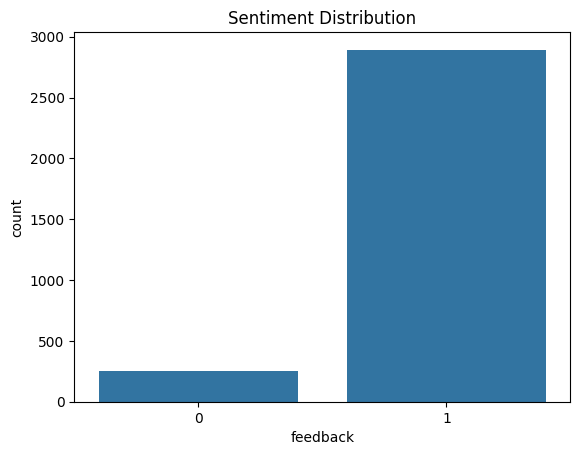

feedback
1    2893
0     256
Name: count, dtype: int64

In [7]:

sns.countplot(x="feedback", data=df)
plt.title("Sentiment Distribution")
plt.show()

df["feedback"].value_counts()



If the dataset is imbalanced, models may learn to predict only the majority class.


## 5. Text Cleaning

In [8]:

def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-z\s]", "", text)
    return text

df["clean_reviews"] = df["verified_reviews"].apply(clean_text)


In [9]:
df.head()

,rating,date,variation,verified_reviews,feedback,clean_reviews
0,5,31-Jul-18,Charcoal Fabric,Love my Echo!,1,love my echo
1,5,31-Jul-18,Charcoal Fabric,Loved it!,1,loved it
2,4,31-Jul-18,Walnut Finish,"Sometimes while playing a game, you can answer...",1,sometimes while playing a game you can answer ...
3,5,31-Jul-18,Charcoal Fabric,I have had a lot of fun with this thing. My 4 ...,1,i have had a lot of fun with this thing my yr...
4,5,31-Jul-18,Charcoal Fabric,Music,1,music


## 6. Review Length Analysis

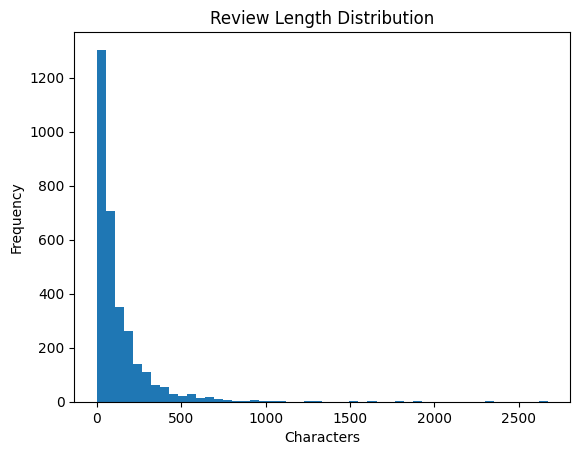

In [10]:

df["review_length"] = df["clean_reviews"].apply(len)

plt.hist(df["review_length"], bins=50)
plt.title("Review Length Distribution")
plt.xlabel("Characters")
plt.ylabel("Frequency")
plt.show()


## 7. Word Cloud

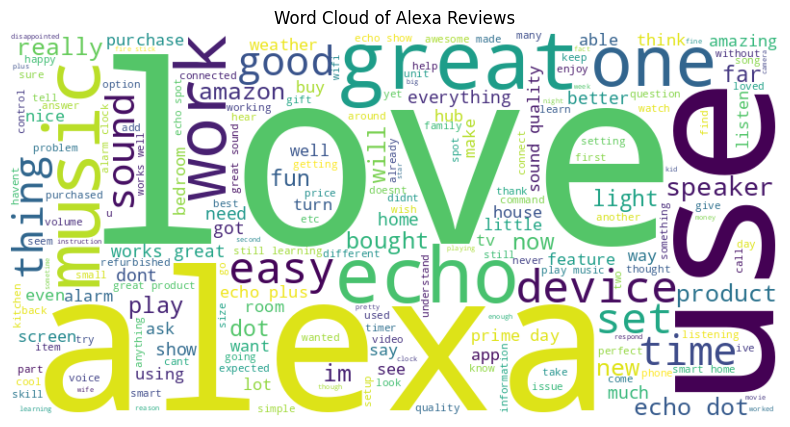

In [11]:

text = " ".join(df["clean_reviews"])

wordcloud = WordCloud(width=800, height=400, background_color="white").generate(text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of Alexa Reviews")
plt.show()


## 8. N‑gram Analysis

In [14]:
vectorizer = CountVectorizer(stop_words="english")
vectorizer.fit(df["clean_reviews"])

sample_x = vectorizer.transform(df["clean_reviews"])

sample_x.toarray()

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

In [19]:
vectorizer.get_feature_names_out()

array(['abay', 'abc', 'abd', ..., 'zwave', 'zzzz', 'zzzzzzz'],
      dtype=object)

In [30]:
sample_x.shape

(3149, 4061)

In [29]:
sample_x.sum(axis=1).shape

(3149, 1)

In [27]:
sample_x.sum(axis=0).shape

(1, 4061)

In [32]:
vectorizer.vocabulary_.items()

dict_items([('love', 2114), ('echo', 1098), ('loved', 2115), ('playing', 2606), ('game', 1449), ('answer', 182), ('question', 2778), ('correctly', 781), ('alexa', 126), ('says', 3056), ('got', 1514), ('wrong', 4022), ('answers', 185), ('like', 2037), ('able', 5), ('turn', 3725), ('lights', 2034), ('away', 292), ('home', 1669), ('lot', 2107), ('fun', 1425), ('thing', 3603), ('yr', 4052), ('old', 2408), ('learns', 2006), ('dinosaurs', 976), ('control', 753), ('play', 2603), ('games', 1450), ('categories', 533), ('nice', 2340), ('sound', 3303), ('music', 2280), ('received', 2844), ('gift', 1482), ('needed', 2315), ('bluetooth', 397), ('easily', 1094), ('accessible', 16), ('smart', 3247), ('speaker', 3330), ('wait', 3894), ('having', 1608), ('cellphone', 546), ('use', 3815), ('features', 1325), ('ipad', 1865), ('great', 1536), ('alarm', 116), ('deaf', 869), ('hear', 1620), ('bedroom', 343), ('living', 2067), ('room', 3009), ('reason', 2833), ('herit', 1640), ('ask', 240), ('random', 2803),

In [13]:

vectorizer = CountVectorizer(stop_words="english", ngram_range=(1,2))

X_counts = vectorizer.fit_transform(df["clean_reviews"])
sum_words = X_counts.sum(axis=0)

words_freq = [(word, sum_words[0, idx]) for word, idx in vectorizer.vocabulary_.items()]
words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)

words_freq[:20]


[('love', 951),
 ('echo', 826),
 ('great', 717),
 ('alexa', 613),
 ('music', 525),
 ('like', 501),
 ('use', 465),
 ('works', 378),
 ('easy', 337),
 ('sound', 334),
 ('just', 328),
 ('set', 296),
 ('dot', 282),
 ('good', 273),
 ('amazon', 251),
 ('product', 249),
 ('speaker', 236),
 ('im', 232),
 ('home', 215),
 ('play', 215)]

## 9. Prepare Features

In [14]:

X = df["clean_reviews"]
y = df["feedback"]


## 10. Stratified Train/Test Split

In [15]:

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training size:", X_train.shape)
print("Test size:", X_test.shape)


Training size: (2519,)
Test size: (630,)


## 11. TF‑IDF + Model Pipeline

In [16]:

tfidf = TfidfVectorizer(
    stop_words="english",
    ngram_range=(1,2),
    max_features=10000,
    min_df=2
)


## 12. Model Comparison

In [17]:

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "Naive Bayes": MultinomialNB(),
    "SVM": LinearSVC(class_weight="balanced")
}

results = {}

for name, model in models.items():
    
    pipeline = Pipeline([
        ("tfidf", tfidf),
        ("model", model)
    ])
    
    pipeline.fit(X_train, y_train)
    preds = pipeline.predict(X_test)
    
    acc = accuracy_score(y_test, preds)
    results[name] = acc
    
    print("\n", name)
    print("Accuracy:", acc)
    print(classification_report(y_test, preds))



 Logistic Regression
Accuracy: 0.9222222222222223
              precision    recall  f1-score   support

           0       0.51      0.75      0.61        51
           1       0.98      0.94      0.96       579

    accuracy                           0.92       630
   macro avg       0.75      0.84      0.78       630
weighted avg       0.94      0.92      0.93       630


 Naive Bayes
Accuracy: 0.919047619047619
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        51
           1       0.92      1.00      0.96       579

    accuracy                           0.92       630
   macro avg       0.46      0.50      0.48       630
weighted avg       0.84      0.92      0.88       630


 SVM
Accuracy: 0.9063492063492063
              precision    recall  f1-score   support

           0       0.45      0.69      0.54        51
           1       0.97      0.93      0.95       579

    accuracy                           0.91       630


/opt/envs/ds/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/envs/ds/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/envs/ds/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


## 13. Model Accuracy Comparison

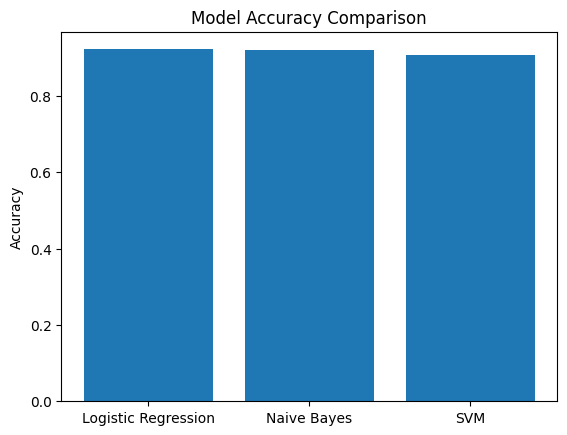

In [18]:

plt.bar(results.keys(), results.values())
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()


## 14. Confusion Matrix (Logistic Regression)

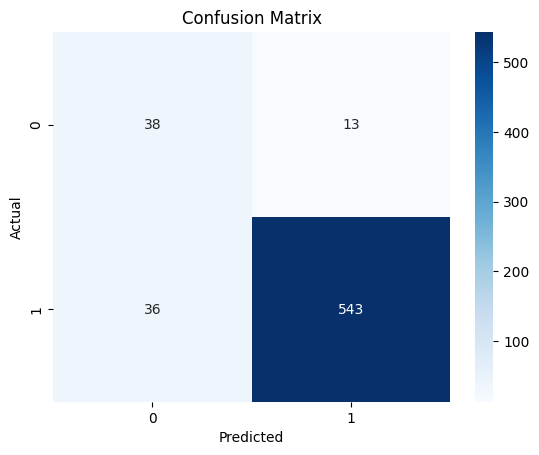

In [19]:

pipeline = Pipeline([
    ("tfidf", tfidf),
    ("model", LogisticRegression(max_iter=1000, class_weight="balanced"))
])

pipeline.fit(X_train, y_train)
preds = pipeline.predict(X_test)

cm = confusion_matrix(y_test, preds)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()
